# 1. 코호트 환자 상세 임상 기록 추출

In [1]:
#!/usr/bin/env python3
"""
코호트 환자별 상세 임상 기록 추출
- Lab / Vitals / Culture / Medication
- 1:n 매칭으로 전체 기록 추출
- 시각화 및 JSON 저장
"""

import duckdb
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 경로 설정
# ============================================

DB_PATH = '../mimic_total.duckdb'
COHORT_CSV = '../outputs/cohort_patients_v4.csv'
OUTPUT_DIR = '../outputs/patient_details'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("코호트 환자 상세 임상 기록 추출")
print("=" * 70)

코호트 환자 상세 임상 기록 추출


---
## 0. 코호트 로드 및 DuckDB 연결

In [2]:
# ============================================
# 코호트 로드 및 DuckDB 연결
# ============================================

print("\n[Step 0] 코호트 및 DB 연결...")

# 코호트 로드
cohort = pd.read_csv(COHORT_CSV)
print(f"  코호트 환자 수: {cohort['subject_id'].nunique()}명")
print(f"  코호트 입원 수: {cohort['hadm_id'].nunique()}건")

# hadm_id 리스트
hadm_ids = cohort['hadm_id'].unique().tolist()
subject_ids = cohort['subject_id'].unique().tolist()

# DuckDB 연결
conn = duckdb.connect(DB_PATH, read_only=True)
print("  ✅ DuckDB 연결 성공")

# 코호트 정보 출력
print("\n[코호트 구성]")
print(cohort.groupby(['cohort_type', 'subcategory']).size().to_string())


[Step 0] 코호트 및 DB 연결...
  코호트 환자 수: 147명
  코호트 입원 수: 148건
  ✅ DuckDB 연결 성공

[코호트 구성]
cohort_type  subcategory 
Infection    GI_Infection    62
             Pneumonia       56
             UTI             53
MDRO         CRE              4
             MRSA             8


---
## 1. Lab 기록 추출

In [3]:
# ============================================
# Lab 기록 추출
# ============================================

print("\n[Step 1] Lab 기록 추출...")

hadm_id_str = ','.join(map(str, hadm_ids))

lab_query = f"""
SELECT 
    le.subject_id,
    le.hadm_id,
    le.charttime,
    le.itemid,
    di.label AS lab_name,
    di.category,
    le.value,
    le.valuenum,
    le.valueuom,
    le.flag,
    le.ref_range_lower,
    le.ref_range_upper
FROM labevents le
LEFT JOIN d_labitems di ON le.itemid = di.itemid
WHERE le.hadm_id IN ({hadm_id_str})
ORDER BY le.hadm_id, le.charttime
"""

lab_df = conn.execute(lab_query).df()
lab_df['hadm_id'] = lab_df['hadm_id'].astype(int)
print(f"  Lab 기록: {len(lab_df):,}건")
print(f"  고유 검사 항목: {lab_df['lab_name'].nunique()}개")

# 주요 랩 항목 확인
print("\n  [주요 검사 항목 Top 20]")
print(lab_df['lab_name'].value_counts().head(20).to_string())


[Step 1] Lab 기록 추출...
  Lab 기록: 198,943건
  고유 검사 항목: 457개

  [주요 검사 항목 Top 20]
lab_name
Glucose              6479
Potassium            5390
Hematocrit           5305
Sodium               5268
Platelet Count       5236
Chloride             5202
Creatinine           5189
Urea Nitrogen        5158
Bicarbonate          5121
Anion Gap            5090
Hemoglobin           5049
Magnesium            4985
White Blood Cells    4871
Phosphate            4856
MCHC                 4851
MCH                  4849
MCV                  4849
Red Blood Cells      4849
RDW                  4847
Calcium, Total       4841


---
## 2. Vitals 기록 추출 (chartevents)

In [4]:
# ============================================
# Vitals 기록 추출 (chartevents에서)
# ============================================

print("\n[Step 2] Vitals 기록 추출...")

# 주요 vital signs item IDs (MIMIC-IV 기준)
vital_items = {
    220045: 'Heart Rate',
    220050: 'Arterial BP Systolic',
    220051: 'Arterial BP Diastolic',
    220052: 'Arterial BP Mean',
    220179: 'Non-Invasive BP Systolic',
    220180: 'Non-Invasive BP Diastolic',
    220181: 'Non-Invasive BP Mean',
    220210: 'Respiratory Rate',
    223761: 'Temperature (F)',
    223762: 'Temperature (C)',
    220277: 'SpO2',
    220739: 'GCS Eye',
    223900: 'GCS Verbal',
    223901: 'GCS Motor',
}

vital_item_str = ','.join(map(str, vital_items.keys()))

vitals_query = f"""
SELECT 
    ce.subject_id,
    ce.hadm_id,
    ce.charttime,
    ce.itemid,
    di.label AS vital_name,
    ce.value,
    ce.valuenum,
    ce.valueuom
FROM chartevents ce
LEFT JOIN d_items di ON ce.itemid = di.itemid
WHERE ce.hadm_id IN ({hadm_id_str})
  AND ce.itemid IN ({vital_item_str})
ORDER BY ce.hadm_id, ce.charttime
"""

vitals_df = conn.execute(vitals_query).df()
vitals_df['hadm_id'] = vitals_df['hadm_id'].astype(int)
print(f"  Vitals 기록: {len(vitals_df):,}건")
print(f"  고유 vital 항목: {vitals_df['vital_name'].nunique()}개")

print("\n  [Vital 항목별 건수]")
print(vitals_df['vital_name'].value_counts().to_string())


[Step 2] Vitals 기록 추출...
  Vitals 기록: 31,618건
  고유 vital 항목: 14개

  [Vital 항목별 건수]
vital_name
O2 saturation pulseoxymetry              4508
Respiratory Rate                         4494
Heart Rate                               4487
Non Invasive Blood Pressure mean         2501
Non Invasive Blood Pressure systolic     2497
Non Invasive Blood Pressure diastolic    2496
Arterial Blood Pressure diastolic        2154
Arterial Blood Pressure systolic         2154
Arterial Blood Pressure mean             2153
Temperature Fahrenheit                   1147
GCS - Eye Opening                         976
GCS - Motor Response                      975
GCS - Verbal Response                     971
Temperature Celsius                       105


---
## 3. Culture (미생물 검사) 기록 추출

In [5]:
# ============================================
# Culture (미생물 검사) 기록 추출
# ============================================

print("\n[Step 3] Culture 기록 추출...")

culture_query = f"""
SELECT 
    me.subject_id,
    me.hadm_id,
    me.chartdate,
    me.charttime,
    me.spec_type_desc,
    me.org_name,
    me.isolate_num,
    me.ab_name,
    me.dilution_text,
    me.dilution_comparison,
    me.dilution_value,
    me.interpretation
FROM microbiologyevents me
WHERE me.hadm_id IN ({hadm_id_str})
ORDER BY me.hadm_id, me.chartdate, me.charttime
"""

culture_df = conn.execute(culture_query).df()
culture_df['hadm_id'] = culture_df['hadm_id'].astype(int)
print(f"  Culture 기록: {len(culture_df):,}건")
print(f"  고유 균주: {culture_df['org_name'].nunique()}개")
print(f"  고유 검체: {culture_df['spec_type_desc'].nunique()}개")

print("\n  [검출 균주 Top 15]")
print(culture_df['org_name'].value_counts().head(15).to_string())

print("\n  [검체 종류별 건수]")
print(culture_df['spec_type_desc'].value_counts().head(10).to_string())


[Step 3] Culture 기록 추출...
  Culture 기록: 7,570건
  고유 균주: 73개
  고유 검체: 47개

  [검출 균주 Top 15]
org_name
PSEUDOMONAS AERUGINOSA                498
STAPH AUREUS COAG +                   466
KLEBSIELLA PNEUMONIAE                 431
ESCHERICHIA COLI                      250
ENTEROBACTER CLOACAE                  148
ENTEROCOCCUS SP.                      147
STAPHYLOCOCCUS, COAGULASE NEGATIVE    141
YEAST                                 126
ENTEROCOCCUS FAECIUM                   82
PROTEUS MIRABILIS                      66
BURKHOLDERIA CEPACIA GROUP             56
CLOSTRIDIUM DIFFICILE                  48
SERRATIA MARCESCENS                    48
CITROBACTER FREUNDII COMPLEX           34
ENTEROBACTER SPECIES                   28

  [검체 종류별 건수]
spec_type_desc
BLOOD CULTURE             1698
SPUTUM                    1650
URINE                     1243
STOOL                      638
SWAB                       489
BRONCHOALVEOLAR LAVAGE     389
TISSUE                     224
CATHETER TIP-IV       

---
## 4. Medication 기록 추출 (pharmacy + prescriptions)

In [6]:
# ============================================
# Medication 기록 추출 (pharmacy + prescriptions)
# ============================================

print("\n[Step 4] Medication 기록 추출...")

# Pharmacy 테이블
pharmacy_query = f"""
SELECT 
    subject_id,
    hadm_id,
    starttime,
    stoptime,
    medication,
    route,
    frequency,
    doses_per_24_hrs,
    status
FROM pharmacy
WHERE hadm_id IN ({hadm_id_str})
ORDER BY hadm_id, starttime
"""

pharmacy_df = conn.execute(pharmacy_query).df()
print(f"  Pharmacy 기록: {len(pharmacy_df):,}건")

# Prescriptions 테이블 (더 상세한 정보)
prescriptions_query = f"""
SELECT 
    subject_id,
    hadm_id,
    starttime,
    stoptime,
    drug,
    drug_type,
    prod_strength,
    dose_val_rx,
    dose_unit_rx,
    form_val_disp,
    form_unit_disp,
    route
FROM prescriptions
WHERE hadm_id IN ({hadm_id_str})
ORDER BY hadm_id, starttime
"""

prescriptions_df = conn.execute(prescriptions_query).df()
pharmacy_df['hadm_id'] = pharmacy_df['hadm_id'].astype(int)
prescriptions_df['hadm_id'] = prescriptions_df['hadm_id'].astype(int)
print(f"  Prescriptions 기록: {len(prescriptions_df):,}건")

print("\n  [주요 약물 Top 20 (Pharmacy)]")
print(pharmacy_df['medication'].value_counts().head(20).to_string())

# 항생제 필터링
antibiotics_keywords = [
    'cillin', 'mycin', 'floxacin', 'cycline', 'sulfa', 'metro', 
    'vanco', 'cef', 'carba', 'penem', 'azole', 'oxacin'
]

def is_antibiotic(med_name):
    if pd.isna(med_name):
        return False
    med_lower = str(med_name).lower()
    return any(kw in med_lower for kw in antibiotics_keywords)

pharmacy_df['is_antibiotic'] = pharmacy_df['medication'].apply(is_antibiotic)
abx_df = pharmacy_df[pharmacy_df['is_antibiotic']].copy()
print(f"\n  항생제 처방: {len(abx_df):,}건")
print("\n  [항생제 Top 15]")
print(abx_df['medication'].value_counts().head(15).to_string())


[Step 4] Medication 기록 추출...
  Pharmacy 기록: 22,312건
  Prescriptions 기록: 26,127건

  [주요 약물 Top 20 (Pharmacy)]
medication
Insulin                        1053
Furosemide                      991
Potassium Chloride              832
Vancomycin                      522
Acetaminophen                   466
HYDROmorphone (Dilaudid)        399
Metoprolol Tartrate             398
Sodium Chloride 0.9%  Flush     379
Heparin                         372
Magnesium Sulfate               365
Lorazepam                       352
Metoprolol                      337
Pantoprazole                    236
MetRONIDAZOLE (FLagyl)          236
Ondansetron                     236
Warfarin                        233
Morphine Sulfate                204
Fentanyl Citrate                199
Docusate Sodium                 178
Albuterol 0.083% Neb Soln       178

  항생제 처방: 3,502건

  [항생제 Top 15]
medication
Vancomycin                                                    522
Magnesium Sulfate                               

### +) 진단 기록 추출 (참고용)

In [7]:
# ============================================
# 진단 기록 추출 (참고용)
# ============================================

print("\n(+) 진단 기록 추출...")

diagnosis_query = f"""
SELECT 
    di.subject_id,
    di.hadm_id,
    di.seq_num,
    di.icd_code,
    di.icd_version,
    icd.long_title
FROM diagnoses_icd di
LEFT JOIN d_icd_diagnoses icd 
    ON di.icd_code = icd.icd_code AND di.icd_version = icd.icd_version
WHERE di.hadm_id IN ({hadm_id_str})
ORDER BY di.hadm_id, di.seq_num
"""

diagnosis_df = conn.execute(diagnosis_query).df()
diagnosis_df['hadm_id'] = diagnosis_df['hadm_id'].astype(int)
print(f"  진단 기록: {len(diagnosis_df):,}건")
print(f"  고유 진단코드: {diagnosis_df['icd_code'].nunique()}개")


(+) 진단 기록 추출...
  진단 기록: 3,092건
  고유 진단코드: 1187개


---
## 5. 환자별 데이터 통합 및 JSON 저장

In [8]:
# ============================================
# 환자별 데이터 통합 및 JSON 저장
# ============================================

print("\n[Step 5] 환자별 데이터 통합...")

def get_patient_data(hadm_id):
    """특정 입원의 모든 데이터를 딕셔너리로 반환"""
    
    # 코호트 기본 정보
    patient_info = cohort[cohort['hadm_id'] == hadm_id].iloc[0].to_dict()
    
    # Lab
    patient_lab = lab_df[lab_df['hadm_id'] == hadm_id].copy()
    patient_lab['charttime'] = patient_lab['charttime'].astype(str)
    patient_lab = patient_lab.replace({np.nan: None})
    
    # Vitals
    patient_vitals = vitals_df[vitals_df['hadm_id'] == hadm_id].copy()
    patient_vitals['charttime'] = patient_vitals['charttime'].astype(str)
    patient_vitals = patient_vitals.replace({np.nan: None})
    
    # Culture
    patient_culture = culture_df[culture_df['hadm_id'] == hadm_id].copy()
    patient_culture['chartdate'] = patient_culture['chartdate'].astype(str)
    patient_culture['charttime'] = patient_culture['charttime'].astype(str)
    patient_culture = patient_culture.replace({np.nan: None})
    
    # Medications
    patient_meds = pharmacy_df[pharmacy_df['hadm_id'] == hadm_id].copy()
    patient_meds['starttime'] = patient_meds['starttime'].astype(str)
    patient_meds['stoptime'] = patient_meds['stoptime'].astype(str)
    patient_meds = patient_meds.replace({np.nan: None})
    
    # Diagnosis
    patient_dx = diagnosis_df[diagnosis_df['hadm_id'] == hadm_id].copy()
    patient_dx = patient_dx.replace({np.nan: None})
    
    return {
        'info': {k: (None if pd.isna(v) else v) for k, v in patient_info.items()},
        'summary': {
            'lab_count': len(patient_lab),
            'vitals_count': len(patient_vitals),
            'culture_count': len(patient_culture),
            'medication_count': len(patient_meds),
            'diagnosis_count': len(patient_dx),
            'unique_organisms': patient_culture['org_name'].dropna().unique().tolist(),
            'antibiotics_used': patient_meds[patient_meds['is_antibiotic']]['medication'].unique().tolist()
        },
        'lab': patient_lab.to_dict(orient='records'),
        'vitals': patient_vitals.to_dict(orient='records'),
        'culture': patient_culture.to_dict(orient='records'),
        'medications': patient_meds.to_dict(orient='records'),
        'diagnosis': patient_dx.to_dict(orient='records')
    }

# 전체 환자 데이터 생성
all_patients_data = {}
for hadm_id in hadm_ids:
    all_patients_data[str(hadm_id)] = get_patient_data(hadm_id)
    
print(f"  ✅ {len(all_patients_data)}명 데이터 통합 완료")

# JSON 저장
output_json_path = os.path.join(OUTPUT_DIR, 'cohort_patient_details.json')
with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(all_patients_data, f, indent=2, ensure_ascii=False, default=str)
print(f"  ✅ JSON 저장: {output_json_path}")


[Step 5] 환자별 데이터 통합...
  ✅ 148명 데이터 통합 완료
  ✅ JSON 저장: ../outputs/patient_details/cohort_patient_details.json


---
# 2. 환자 임상 기록 요약 및 통계
## 1. 환자 요약 테이블

In [9]:
# ============================================
# 환자 요약 테이블
# ============================================

print("\n[Step 1] 환자 요약 테이블 생성...")

summary_rows = []
for hadm_id, data in all_patients_data.items():
    row = {
        'hadm_id': hadm_id,
        'subject_id': data['info']['subject_id'],
        'cohort_type': data['info']['cohort_type'],
        'subcategory': data['info']['subcategory'],
        'gender': data['info']['gender'],
        'age': data['info']['age'],
        'los_days': round(data['info']['los_days'], 1),
        'lab_count': data['summary']['lab_count'],
        'vitals_count': data['summary']['vitals_count'],
        'culture_count': data['summary']['culture_count'],
        'medication_count': data['summary']['medication_count'],
        'diagnosis_count': data['summary']['diagnosis_count'],
        'organism_count': len(data['summary']['unique_organisms']),
        'organisms': ', '.join(data['summary']['unique_organisms'][:3]),  # 상위 3개
        'abx_count': len(data['summary']['antibiotics_used']),
        'antibiotics': ', '.join(data['summary']['antibiotics_used'][:5])  # 상위 5개
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['cohort_type', 'subcategory', 'hadm_id'])

# CSV 저장
summary_csv_path = os.path.join(OUTPUT_DIR, 'cohort_patient_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"  ✅ 요약 테이블 저장: {summary_csv_path}")

print("\n[환자 요약 테이블 미리보기]")
print(summary_df.head(20).to_string())


[Step 1] 환자 요약 테이블 생성...
  ✅ 요약 테이블 저장: ../outputs/patient_details/cohort_patient_summary.csv

[환자 요약 테이블 미리보기]
      hadm_id  subject_id cohort_type   subcategory gender  age  los_days  lab_count  vitals_count  culture_count  medication_count  diagnosis_count  organism_count                                                                   organisms  abx_count                                                                                                                              antibiotics
92   20057926    19096027   Infection  GI_Infection      M   59      18.6        880             0             28               186               12               4                  STAPH AUREUS COAG +, YEAST, BETA STREPTOCOCCI, NOT GROUP A          7                                               Pantoprazole, Vancomycin, Levofloxacin, MetRONIDAZOLE (FLagyl), Piperacillin-Tazobactam Na
61   20086040    18003081   Infection  GI_Infection      M   51      28.4        960             0           

## 2. 시각화 - 코호트별 데이터 분포


[Step 2] 시각화


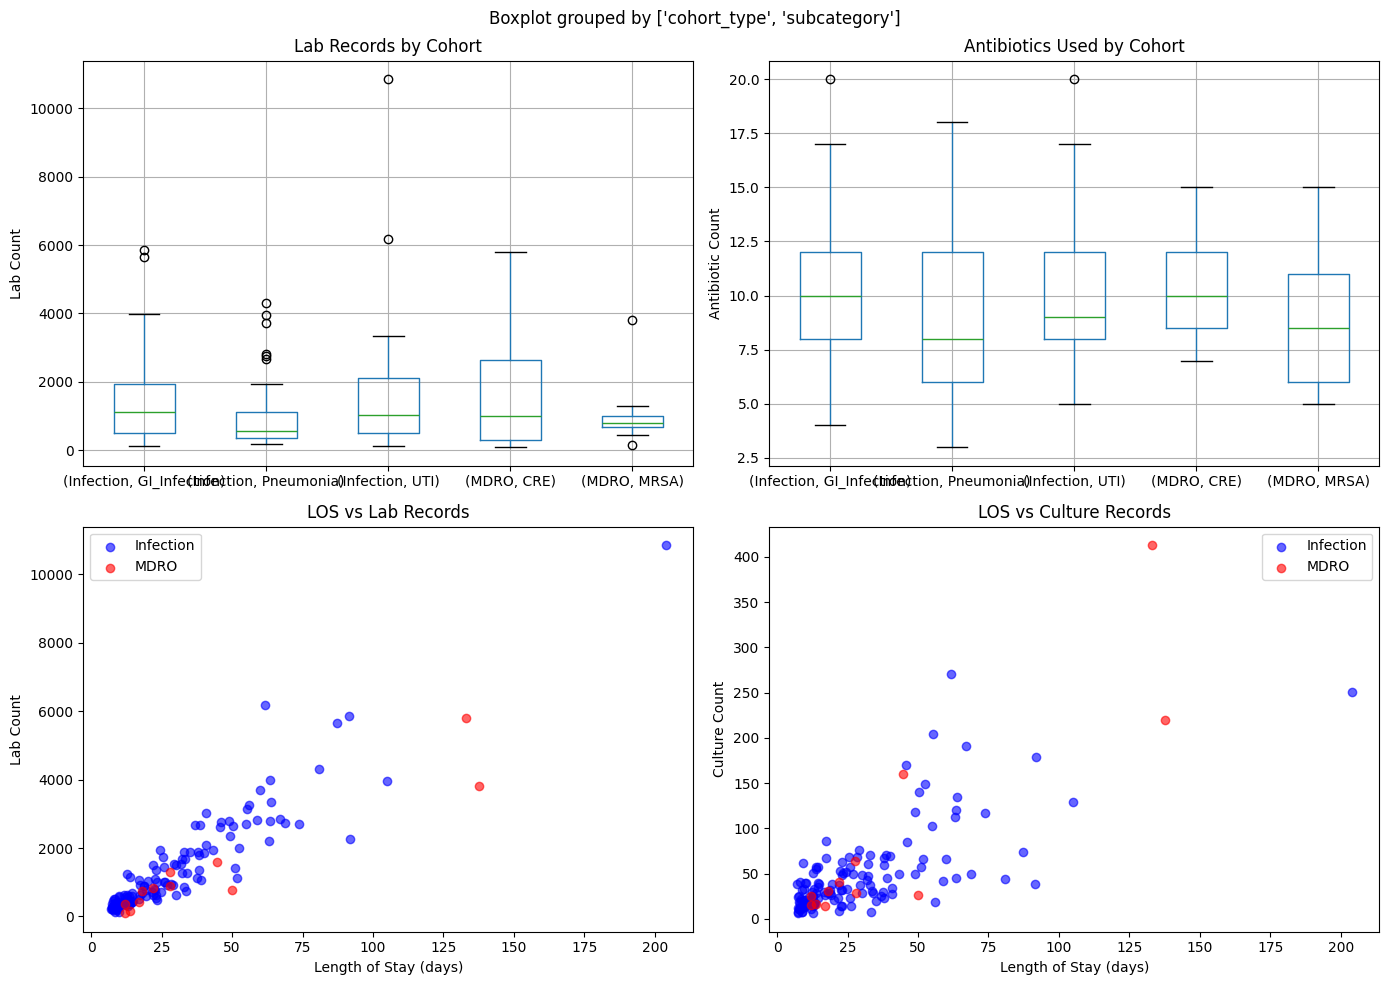

  ✅ 분포 차트 저장 완료


In [10]:
# ============================================
# 시각화 1: 코호트별 데이터 분포
# ============================================

print("\n[Step 2] 시각화")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 코호트별 Lab 건수
ax1 = axes[0, 0]
summary_df.boxplot(column='lab_count', by=['cohort_type', 'subcategory'], ax=ax1)
ax1.set_title('Lab Records by Cohort')
ax1.set_xlabel('')
ax1.set_ylabel('Lab Count')
plt.suptitle('')

# 2. 코호트별 항생제 수
ax2 = axes[0, 1]
summary_df.boxplot(column='abx_count', by=['cohort_type', 'subcategory'], ax=ax2)
ax2.set_title('Antibiotics Used by Cohort')
ax2.set_xlabel('')
ax2.set_ylabel('Antibiotic Count')

# 3. 재원일수 vs Lab 건수
ax3 = axes[1, 0]
colors = {'MDRO': 'red', 'Infection': 'blue'}
for cohort_type in summary_df['cohort_type'].unique():
    subset = summary_df[summary_df['cohort_type'] == cohort_type]
    ax3.scatter(subset['los_days'], subset['lab_count'], 
                alpha=0.6, label=cohort_type, c=colors.get(cohort_type, 'gray'))
ax3.set_xlabel('Length of Stay (days)')
ax3.set_ylabel('Lab Count')
ax3.set_title('LOS vs Lab Records')
ax3.legend()

# 4. 재원일수 vs Culture 건수
ax4 = axes[1, 1]
for cohort_type in summary_df['cohort_type'].unique():
    subset = summary_df[summary_df['cohort_type'] == cohort_type]
    ax4.scatter(subset['los_days'], subset['culture_count'], 
                alpha=0.6, label=cohort_type, c=colors.get(cohort_type, 'gray'))
ax4.set_xlabel('Length of Stay (days)')
ax4.set_ylabel('Culture Count')
ax4.set_title('LOS vs Culture Records')
ax4.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cohort_data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ 분포 차트 저장 완료")

## 3. 시각화 - 개별 환자 타임라인


[샘플 환자 타임라인 시각화]


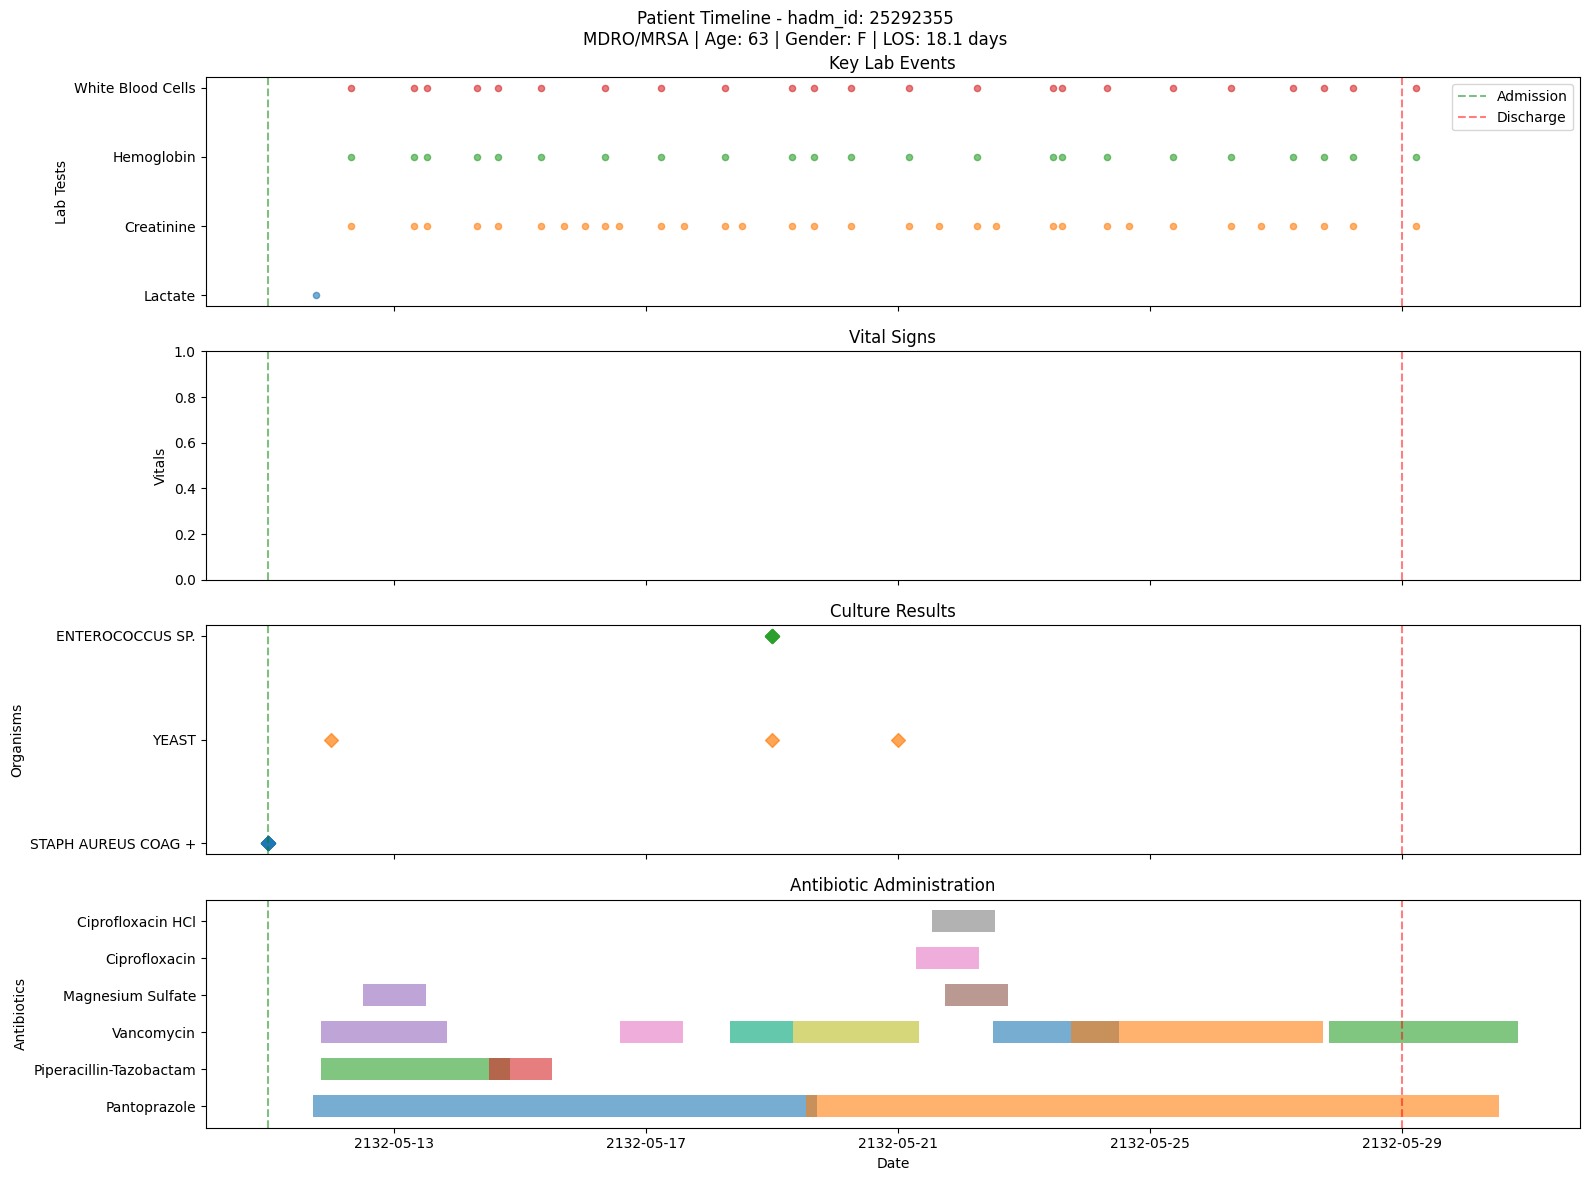

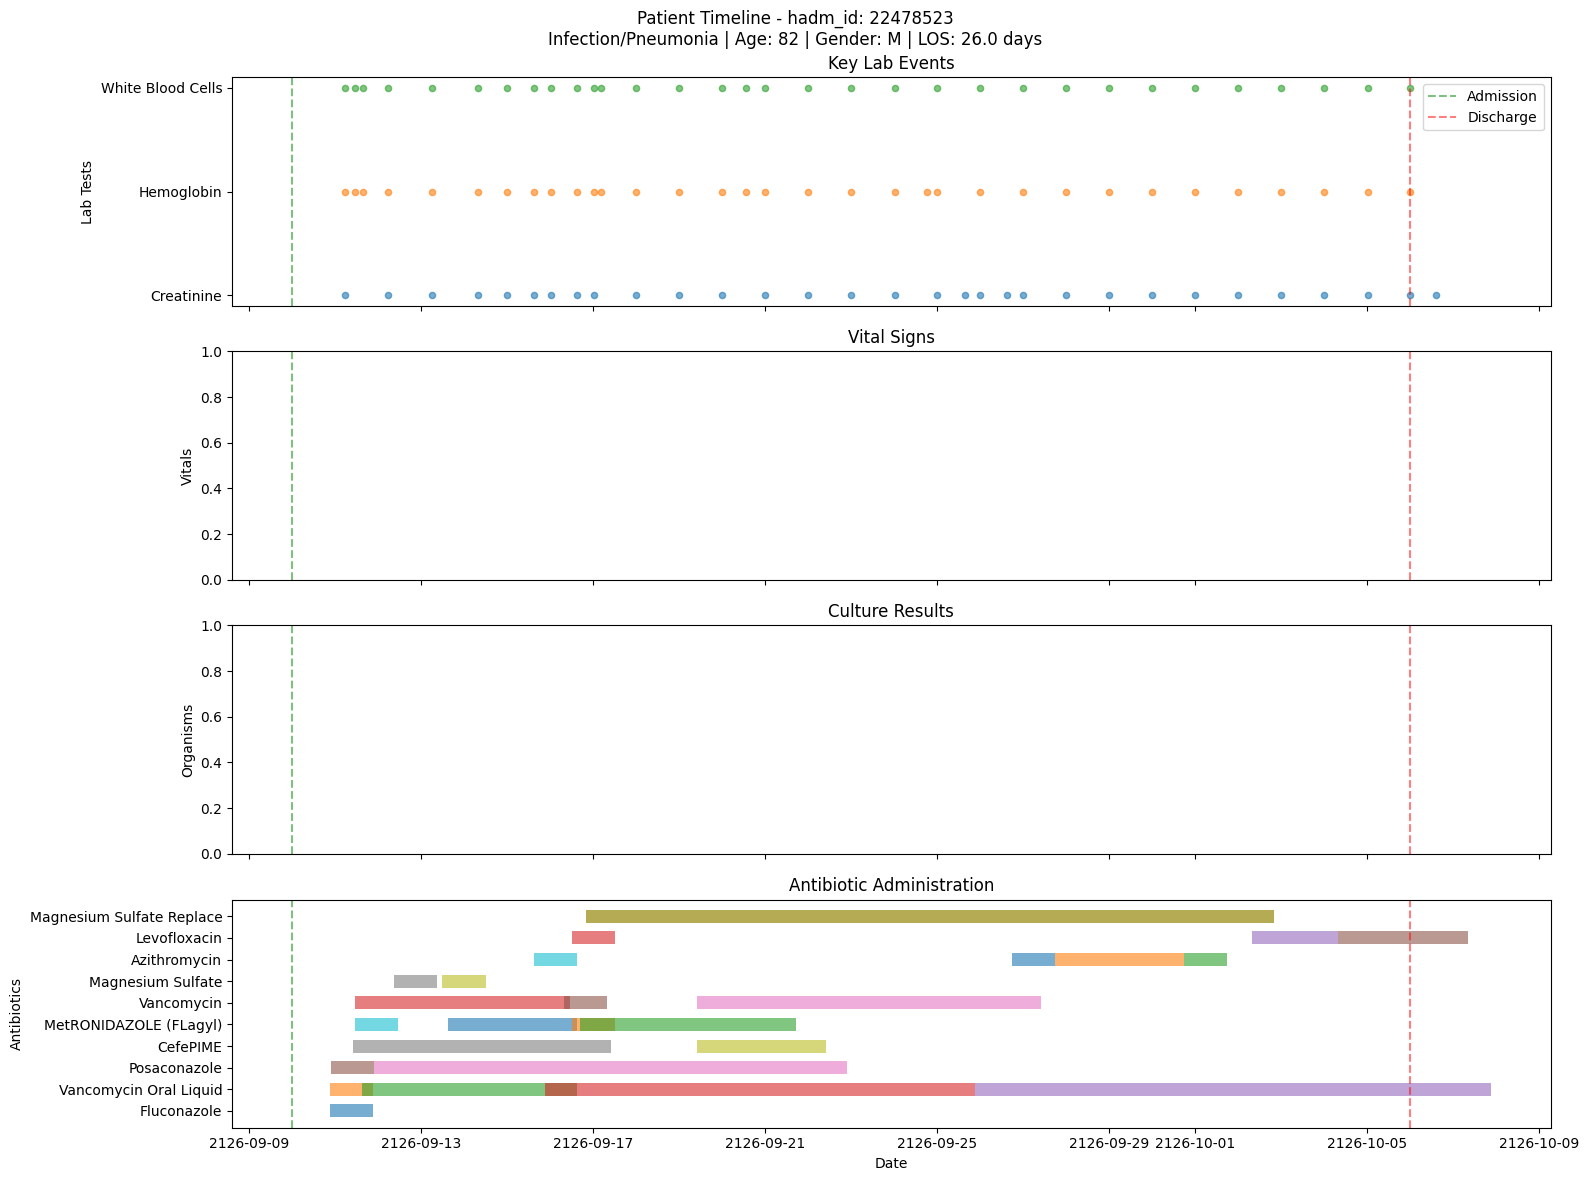

In [11]:
# ============================================
# 시각화 2: 개별 환자 타임라인 (샘플)
# ============================================

def plot_patient_timeline(hadm_id, save_path=None):
    """개별 환자의 임상 이벤트 타임라인 시각화"""
    
    data = all_patients_data[str(hadm_id)]
    info = data['info']
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f"Patient Timeline - hadm_id: {hadm_id}\n"
                 f"{info['cohort_type']}/{info['subcategory']} | "
                 f"Age: {info['age']} | Gender: {info['gender']} | "
                 f"LOS: {info['los_days']:.1f} days", fontsize=12)
    
    admit_date = pd.to_datetime(info['admit_date'])
    discharge_date = pd.to_datetime(info['discharge_date'])
    
    # 1. Lab events (주요 항목만)
    ax1 = axes[0]
    if data['lab']:
        lab_temp = pd.DataFrame(data['lab'])
        lab_temp['charttime'] = pd.to_datetime(lab_temp['charttime'])
        
        # 주요 랩 항목 필터
        key_labs = ['White Blood Cells', 'Creatinine', 'C-Reactive Protein', 
                    'Procalcitonin', 'Lactate', 'Hemoglobin']
        lab_filtered = lab_temp[lab_temp['lab_name'].isin(key_labs)]
        
        for lab_name in lab_filtered['lab_name'].unique():
            subset = lab_filtered[lab_filtered['lab_name'] == lab_name]
            ax1.scatter(subset['charttime'], [lab_name]*len(subset), alpha=0.6, s=20)
    
    ax1.axvline(admit_date, color='green', linestyle='--', alpha=0.5, label='Admission')
    ax1.axvline(discharge_date, color='red', linestyle='--', alpha=0.5, label='Discharge')
    ax1.set_ylabel('Lab Tests')
    ax1.set_title('Key Lab Events')
    ax1.legend(loc='upper right')
    
    # 2. Vitals
    ax2 = axes[1]
    if data['vitals']:
        vitals_temp = pd.DataFrame(data['vitals'])
        vitals_temp['charttime'] = pd.to_datetime(vitals_temp['charttime'])
        
        for vital_name in vitals_temp['vital_name'].unique()[:5]:
            subset = vitals_temp[vitals_temp['vital_name'] == vital_name]
            ax2.scatter(subset['charttime'], [vital_name]*len(subset), alpha=0.6, s=20)
    
    ax2.axvline(admit_date, color='green', linestyle='--', alpha=0.5)
    ax2.axvline(discharge_date, color='red', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Vitals')
    ax2.set_title('Vital Signs')
    
    # 3. Culture
    ax3 = axes[2]
    if data['culture']:
        culture_temp = pd.DataFrame(data['culture'])
        culture_temp['chartdate'] = pd.to_datetime(culture_temp['chartdate'])
        
        organisms = culture_temp['org_name'].dropna().unique()
        for i, org in enumerate(organisms[:5]):
            subset = culture_temp[culture_temp['org_name'] == org]
            ax3.scatter(subset['chartdate'], [org[:30]]*len(subset), alpha=0.7, s=50, marker='D')
    
    ax3.axvline(admit_date, color='green', linestyle='--', alpha=0.5)
    ax3.axvline(discharge_date, color='red', linestyle='--', alpha=0.5)
    ax3.set_ylabel('Organisms')
    ax3.set_title('Culture Results')
    
    # 4. Antibiotics (Gantt-like)
    ax4 = axes[3]
    if data['medications']:
        meds_temp = pd.DataFrame(data['medications'])
        abx_temp = meds_temp[meds_temp['is_antibiotic'] == True].copy()
        
        if len(abx_temp) > 0:
            abx_temp['starttime'] = pd.to_datetime(abx_temp['starttime'])
            abx_temp['stoptime'] = pd.to_datetime(abx_temp['stoptime'])
            
            unique_abx = abx_temp['medication'].unique()[:10]
            for i, abx in enumerate(unique_abx):
                subset = abx_temp[abx_temp['medication'] == abx]
                for _, row in subset.iterrows():
                    start = row['starttime']
                    end = row['stoptime'] if pd.notna(row['stoptime']) else discharge_date
                    ax4.barh(abx[:25], (end - start).days + 1, left=start, alpha=0.6, height=0.6)
    
    ax4.axvline(admit_date, color='green', linestyle='--', alpha=0.5)
    ax4.axvline(discharge_date, color='red', linestyle='--', alpha=0.5)
    ax4.set_ylabel('Antibiotics')
    ax4.set_xlabel('Date')
    ax4.set_title('Antibiotic Administration')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# 샘플 환자 타임라인 (MDRO 1명, Infection 1명)
print("\n[샘플 환자 타임라인 시각화]")

# MDRO 환자 1명
mdro_sample = cohort[cohort['cohort_type'] == 'MDRO']['hadm_id'].iloc[0]
plot_patient_timeline(mdro_sample, 
                      save_path=os.path.join(OUTPUT_DIR, f'timeline_mdro_{mdro_sample}.png'))

# Infection 환자 1명
infection_sample = cohort[cohort['cohort_type'] == 'Infection']['hadm_id'].iloc[0]
plot_patient_timeline(infection_sample,
                      save_path=os.path.join(OUTPUT_DIR, f'timeline_infection_{infection_sample}.png'))

## 4. 특정 환자 상세 조회 함수

In [12]:
# ============================================
# 특정 환자 상세 조회 함수
# ============================================

def view_patient_detail(hadm_id, show_records=5):
    """특정 환자의 상세 정보를 출력"""
    
    data = all_patients_data[str(hadm_id)]
    info = data['info']
    summary = data['summary']
    
    print("=" * 70)
    print(f"환자 상세 정보 - hadm_id: {hadm_id}")
    print("=" * 70)
    
    print(f"\n[기본 정보]")
    print(f"  Subject ID: {info['subject_id']}")
    print(f"  코호트: {info['cohort_type']} / {info['subcategory']}")
    print(f"  나이/성별: {info['age']}세 / {info['gender']}")
    print(f"  입원기간: {info['admit_date']} ~ {info['discharge_date']} ({info['los_days']:.1f}일)")
    
    print(f"\n[데이터 요약]")
    print(f"  Lab: {summary['lab_count']:,}건")
    print(f"  Vitals: {summary['vitals_count']:,}건")
    print(f"  Culture: {summary['culture_count']:,}건")
    print(f"  Medications: {summary['medication_count']:,}건")
    print(f"  Diagnosis: {summary['diagnosis_count']:,}건")
    
    print(f"\n[검출 균주]")
    for org in summary['unique_organisms']:
        print(f"  - {org}")
    
    print(f"\n[사용 항생제]")
    for abx in summary['antibiotics_used']:
        print(f"  - {abx}")
    
    print(f"\n[진단 (상위 {show_records}개)]")
    for dx in data['diagnosis'][:show_records]:
        print(f"  [{dx['seq_num']}] {dx['icd_code']}: {dx['long_title']}")
    
    print(f"\n[Culture 결과 (상위 {show_records}개)]")
    for c in data['culture'][:show_records]:
        print(f"  {c['chartdate']} | {c['spec_type_desc']} | {c['org_name']} | {c['ab_name']} -> {c['interpretation']}")

# 사용 예시
print("\n" + "=" * 70)
print("환자 상세 조회 예시")
print("=" * 70)

# MRSA 환자 조회
mrsa_hadm = cohort[cohort['subcategory'] == 'MRSA']['hadm_id'].iloc[0]
view_patient_detail(mrsa_hadm)


환자 상세 조회 예시
환자 상세 정보 - hadm_id: 25292355

[기본 정보]
  Subject ID: 11438336
  코호트: MDRO / MRSA
  나이/성별: 63세 / F
  입원기간: 2132-05-11 ~ 2132-05-29 (18.1일)

[데이터 요약]
  Lab: 751건
  Vitals: 0건
  Culture: 31건
  Medications: 128건
  Diagnosis: 27건

[검출 균주]
  - STAPH AUREUS COAG +
  - YEAST
  - ENTEROCOCCUS SP.

[사용 항생제]
  - Pantoprazole
  - Piperacillin-Tazobactam
  - Vancomycin
  - Magnesium Sulfate
  - Ciprofloxacin
  - Ciprofloxacin HCl

[진단 (상위 5개)]
  [1] 25080: Diabetes with other specified manifestations, type II or unspecified type, not stated as uncontrolled
  [10] 4280: Congestive heart failure, unspecified
  [11] 40390: Hypertensive chronic kidney disease, unspecified, with chronic kidney disease stage I through stage IV, or unspecified
  [12] 5859: Chronic kidney disease, unspecified
  [13] 3572: Polyneuropathy in diabetes

[Culture 결과 (상위 5개)]
  2132-05-11 00:00:00 | SWAB | STAPH AUREUS COAG + | CLINDAMYCIN -> S
  2132-05-11 00:00:00 | SWAB | STAPH AUREUS COAG + | TRIMETHOPRIM/SULFA -